# Exploratory Data Analysis

## Education Impact Evaluation in Rural Uganda

This notebook explores the characteristics of pupils participating in a hypothetical education support program.

The objective is to understand the structure of the dataset and compare treatment and comparison groups before conducting impact evaluation analyses.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/synthetic_education_data.csv")

df.head

<bound method NDFrame.head of      student_id class_level gender  treatment  attendance_rate  study_hours  \
0             1          P5   Girl          1             92.3          6.6   
1             2          P6    Boy          1             89.8          3.7   
2             3          P5   Girl          1             95.8         10.9   
3             4          P5    Boy          0             81.2          6.3   
4             5          P5    Boy          0             89.4          6.2   
..          ...         ...    ...        ...              ...          ...   
475         236          P6   Girl          1             78.8         10.9   
476         237          P6    Boy          0             76.1          4.7   
477         238          P6   Girl          1             92.5          4.9   
478         239          P5    Boy          1             88.3          4.8   
479         240          P6   Girl          1             84.7          4.9   

     post      time  

In [3]:
df.shape

(480, 9)

In [4]:
df.info

<bound method DataFrame.info of      student_id class_level gender  treatment  attendance_rate  study_hours  \
0             1          P5   Girl          1             92.3          6.6   
1             2          P6    Boy          1             89.8          3.7   
2             3          P5   Girl          1             95.8         10.9   
3             4          P5    Boy          0             81.2          6.3   
4             5          P5    Boy          0             89.4          6.2   
..          ...         ...    ...        ...              ...          ...   
475         236          P6   Girl          1             78.8         10.9   
476         237          P6    Boy          0             76.1          4.7   
477         238          P6   Girl          1             92.5          4.9   
478         239          P5    Boy          1             88.3          4.8   
479         240          P6   Girl          1             84.7          4.9   

     post      time

In [5]:
df.describe

<bound method NDFrame.describe of      student_id class_level gender  treatment  attendance_rate  study_hours  \
0             1          P5   Girl          1             92.3          6.6   
1             2          P6    Boy          1             89.8          3.7   
2             3          P5   Girl          1             95.8         10.9   
3             4          P5    Boy          0             81.2          6.3   
4             5          P5    Boy          0             89.4          6.2   
..          ...         ...    ...        ...              ...          ...   
475         236          P6   Girl          1             78.8         10.9   
476         237          P6    Boy          0             76.1          4.7   
477         238          P6   Girl          1             92.5          4.9   
478         239          P5    Boy          1             88.3          4.8   
479         240          P6   Girl          1             84.7          4.9   

     post      ti

In [6]:
df["class_level"].value_counts

<bound method IndexOpsMixin.value_counts of 0      P5
1      P6
2      P5
3      P5
4      P5
       ..
475    P6
476    P6
477    P6
478    P5
479    P6
Name: class_level, Length: 480, dtype: str>

In [7]:
df["gender"].value_counts

<bound method IndexOpsMixin.value_counts of 0      Girl
1       Boy
2      Girl
3       Boy
4       Boy
       ... 
475    Girl
476     Boy
477    Girl
478     Boy
479    Girl
Name: gender, Length: 480, dtype: str>

In [8]:
df.groupby("treatment")["test_score"].mean()

treatment
0    74.545045
1    78.287597
Name: test_score, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

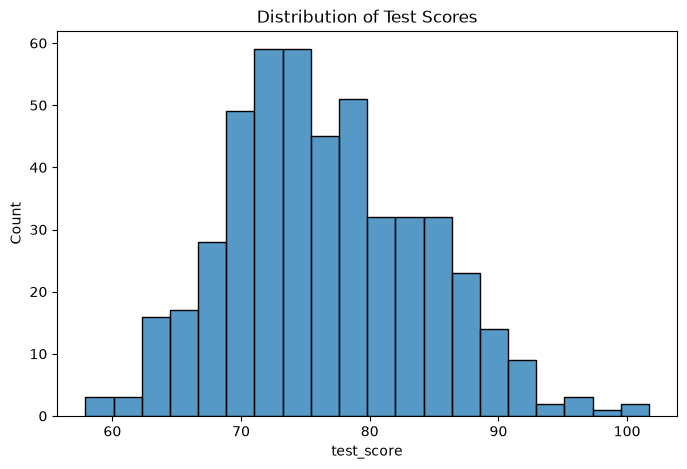

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="test_score",
    bins=20
)

plt.title("Distribution of Test Scores")
plt.show

In [10]:
plt.savefig("../outputs/figures/test_score_distribution.png", 
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Average Test Scores by Program StatusShow more lines


In [11]:
df.groupby("treatment")["test_score"].mean()

treatment
0    74.545045
1    78.287597
Name: test_score, dtype: float64

How the two groups looked like before the intervention

In [12]:
baseline = df[df["post"]== 0]

baseline.groupby("treatment")["test_score"].mean()

treatment
0    72.470270
1    72.600775
Name: test_score, dtype: float64

## Test Score Distribution by Group

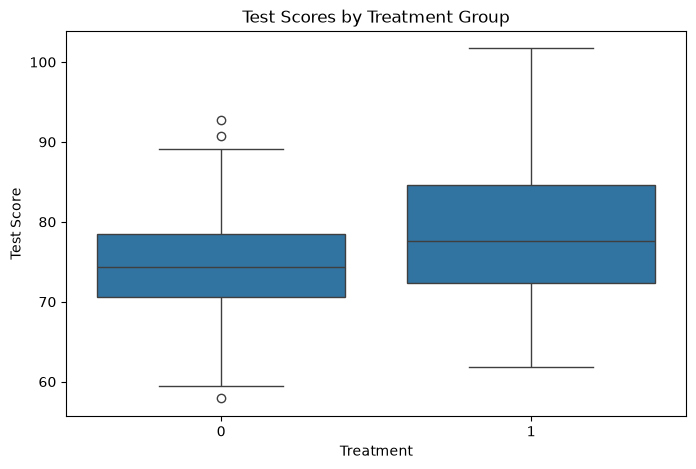

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="treatment",
    y="test_score"
)


plt.title("Test Scores by Treatment Group")
plt.xlabel("Treatment")
plt.ylabel("Test Score")

plt.savefig("../outputs/figures/test_scores_by_treatment.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Attendance Distribution

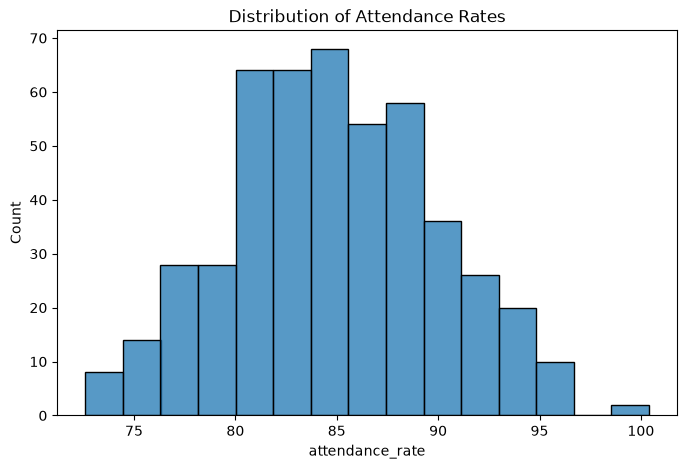

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="attendance_rate",
    bins=15,
)

plt.title("Distribution of Attendance Rates")

plt.savefig("../outputs/figures/attendance_rate_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Study Hours Distribution

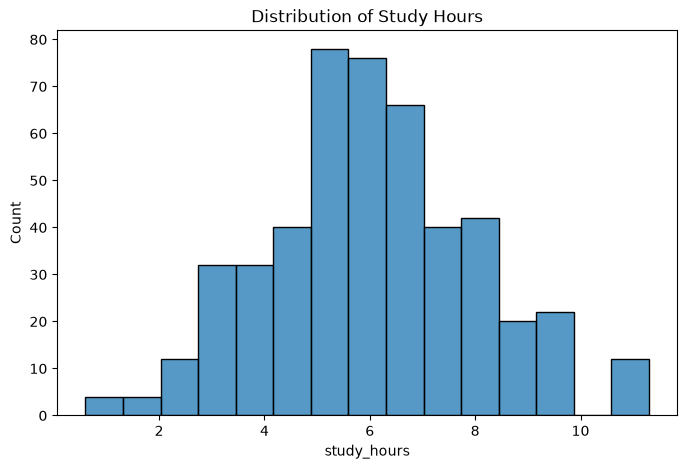

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="study_hours",
    bins=15
)

plt.title("Distribution of Study Hours")

plt.savefig(
    "../outputs/figures/study_hours_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Baseline Balancing

In [16]:
baseline = df[df["post"]== 0]

baseline.groupby("treatment")[
    [
        "attendance_rate",
        "study_hours",
        "test_score"   
    ]        
].mean().round(2)

,attendance_rate,study_hours,test_score
treatment,,,
0,84.64,5.96,72.47
1,84.98,6.09,72.60


In [ ]:
balance_table = baseline.groupby("treatment")[
    [
        "attendance_rate",
        "study_hours",
        "test_score"
    ]
].mean().round(2)

balance_table.to_csv("../outputs/tables/balance_table.csv", index=True)


## Key Findings

- The dataset contains 240 pupils observed at baseline and endline.
- Test score distributions appear approximately normal.
- Treatment and comparison groups show some differences at baseline.
- Attendance and study habits are positively associated with learning outcomes.
- These results motivate the use of causal inference methods such as Difference-in-Differences and Propensity Score Matching in subsequent analyses.